<a href="https://colab.research.google.com/github/sonjoy1s/CNN_Pipeline/blob/main/CNNPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader,Dataset,Subset
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

# Dataset DownLoad from Kaggle

In [51]:
# Download latest version
path = kagglehub.dataset_download("pritpal2873/multiple-skin-disease-detection-and-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'multiple-skin-disease-detection-and-classification' dataset.
Path to dataset files: /kaggle/input/multiple-skin-disease-detection-and-classification


In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [53]:
categories = os.listdir(path)
print(categories)
for root, categories, files in os.walk(path):
  if len(categories) > 1 :
    data_dir = root
    break
Class_found = os.listdir(data_dir)
print("Class Found :",Class_found)

['Skin Cancer Dataset']
Class Found : ['Acitinic Keratosis', 'Pigmented Benign Keratosis', 'Melanoma', 'Vascular Lesion', 'Squamous Cell Carcinoma', 'Basal Cell Carcinoma', 'Seborrheic Keratosis', 'Dermatofibroma', 'Nevus']


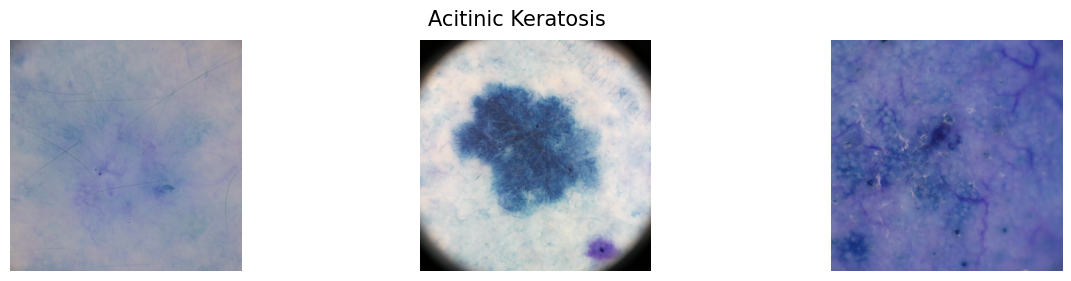

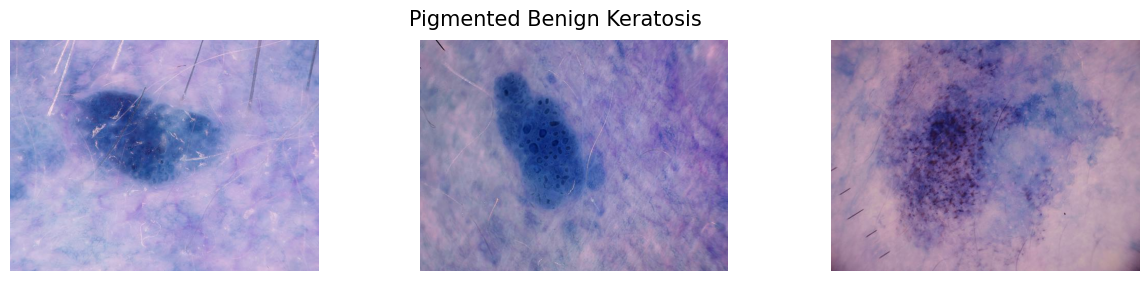

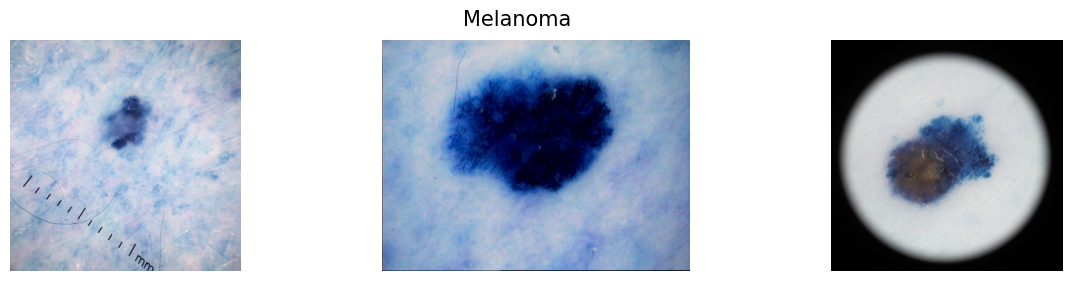

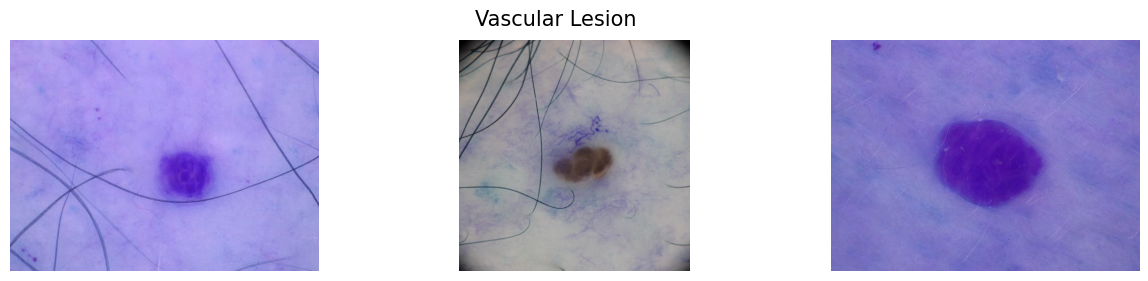

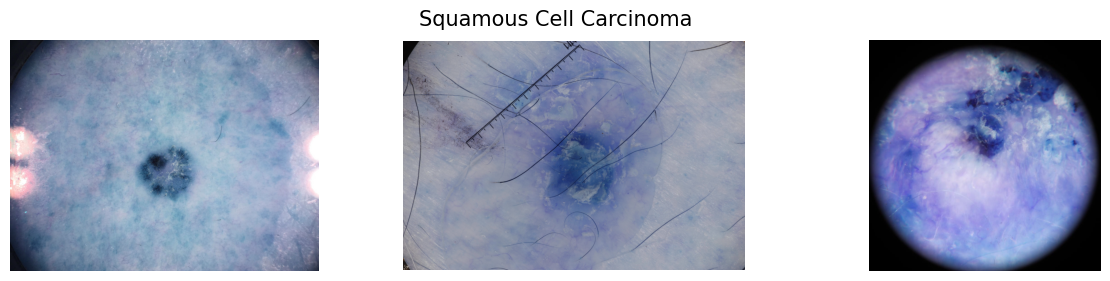

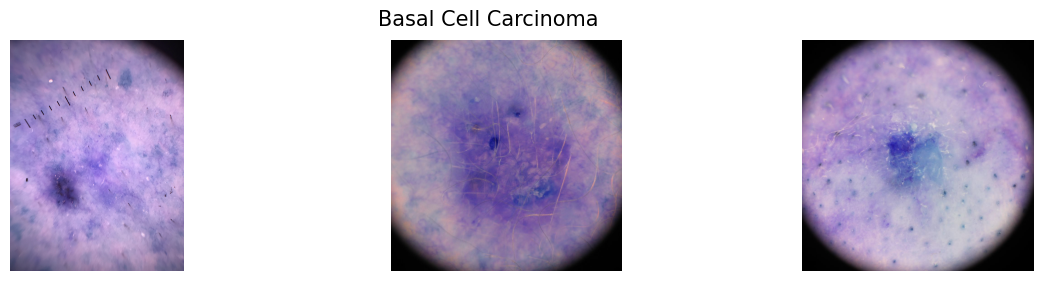

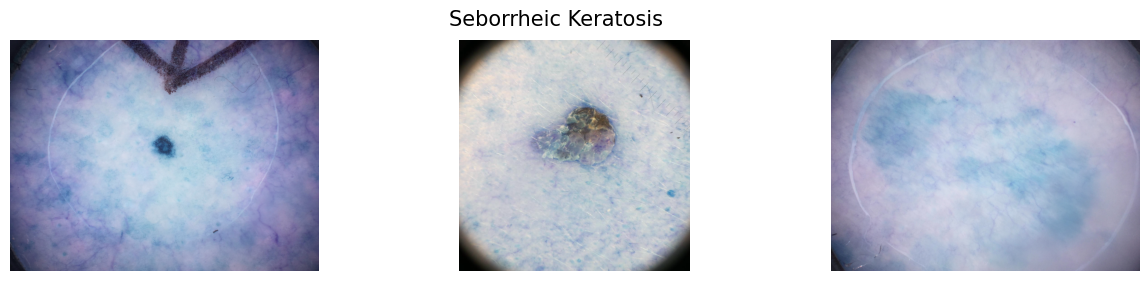

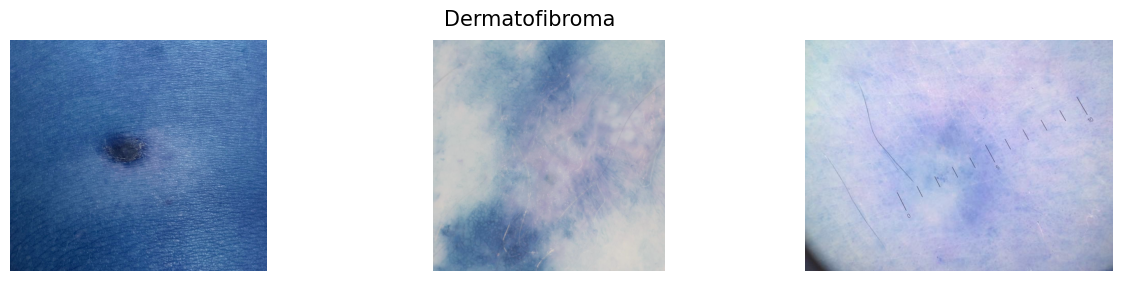

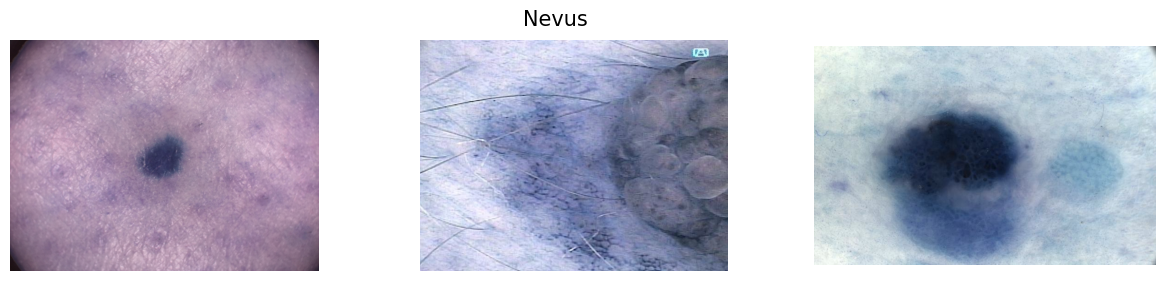

In [54]:
import cv2
import matplotlib.pyplot as plt
for cat in Class_found:
    # Construct the full path for the current category
    category_path = os.path.join(data_dir, cat)
    images = os.listdir(category_path)
    # Initialize a subplot with 1 row and 3 columns
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    fig.suptitle(f'{cat}', fontsize=15)

    for i in range(3):
        # Randomly select an image
        img_name = images[np.random.randint(0, len(images))]
        img_path = os.path.join(category_path, img_name)
        img_array = cv2.imread(img_path)

        # Display the image
        ax[i].imshow(img_array)
        ax[i].axis('off')

In [55]:
full_image_path_list = []
labels = []
for cls in Class_found:
    # Construct the full path for the current category
    class_path = os.path.join(data_dir, cls)
    if not os.path.isdir(class_path):
        continue
    for img in os.listdir(class_path):
        full_image_path_list.append(os.path.join(class_path, img))
        labels.append(cls)

df = pd.DataFrame({
    "image_path": full_image_path_list,
    "label": labels
})


In [56]:
df['label_id'], uniques = pd.factorize(df['label'])
print("Class Names:", uniques.tolist())

Class Names: ['Acitinic Keratosis', 'Pigmented Benign Keratosis', 'Melanoma', 'Vascular Lesion', 'Squamous Cell Carcinoma', 'Basal Cell Carcinoma', 'Seborrheic Keratosis', 'Dermatofibroma', 'Nevus']


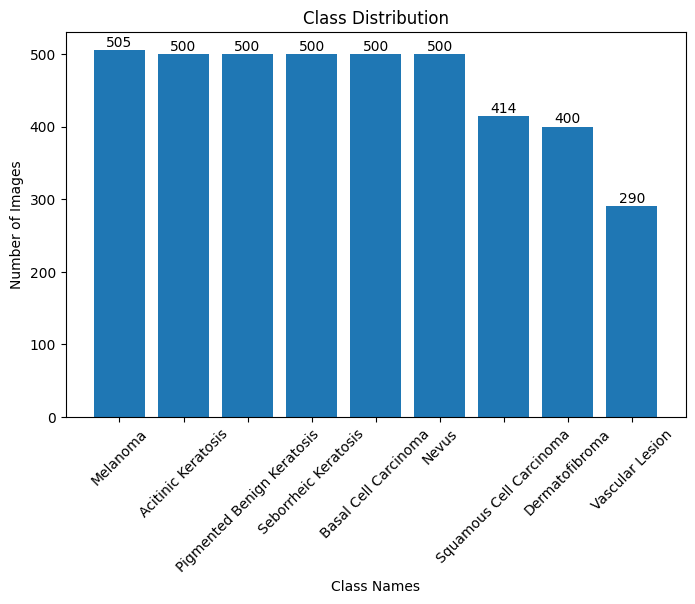

In [57]:
class_counts = df['label'].value_counts()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)

# Labels and title
plt.xlabel("Class Names")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

# Rotate labels for better visibility
plt.xticks(rotation=45)

# Show values on top of bars
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

In [58]:
from sklearn.model_selection import train_test_split

X = df['image_path']
y = df['label_id']

In [59]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [61]:
train_df = pd.DataFrame({'image_path': X_train, 'label_id': y_train}).reset_index(drop=True)
val_df   = pd.DataFrame({'image_path': X_val, 'label_id': y_val}).reset_index(drop=True)
test_df  = pd.DataFrame({'image_path': X_test, 'label_id': y_test}).reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 3287
Val size: 411
Test size: 411


In [62]:
train_patients = set(train_df['image_path'])
val_patients = set(val_df['image_path'])
test_patients = set(test_df['image_path'])

print("Train-Val overlap:", len(train_patients & val_patients))
print("Train-Test overlap:", len(train_patients & test_patients))
print("Val-Test overlap:", len(val_patients & test_patients))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [63]:
print(train_df['label_id'].value_counts(normalize=True))
print(val_df['label_id'].value_counts(normalize=True))
print(test_df['label_id'].value_counts(normalize=True))

label_id
2    0.122908
0    0.121692
6    0.121692
1    0.121692
5    0.121692
8    0.121692
4    0.100700
7    0.097353
3    0.070581
Name: proportion, dtype: float64
label_id
2    0.121655
5    0.121655
1    0.121655
6    0.121655
0    0.121655
8    0.121655
4    0.102190
7    0.097324
3    0.070560
Name: proportion, dtype: float64
label_id
2    0.124088
0    0.121655
6    0.121655
8    0.121655
5    0.121655
1    0.121655
4    0.099757
7    0.097324
3    0.070560
Name: proportion, dtype: float64


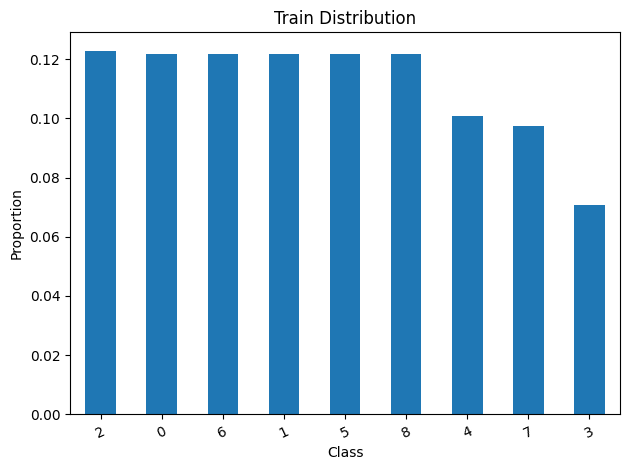

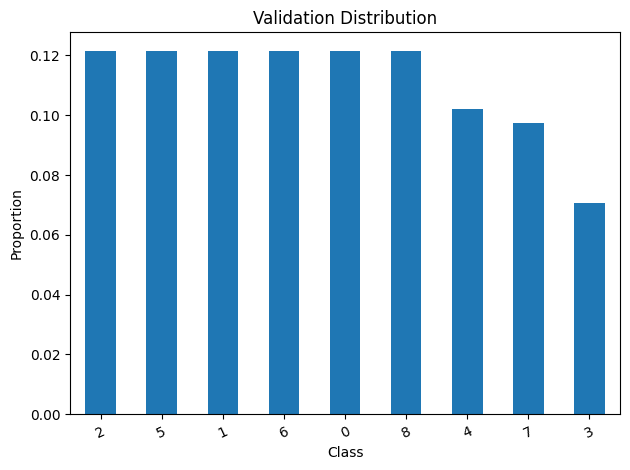

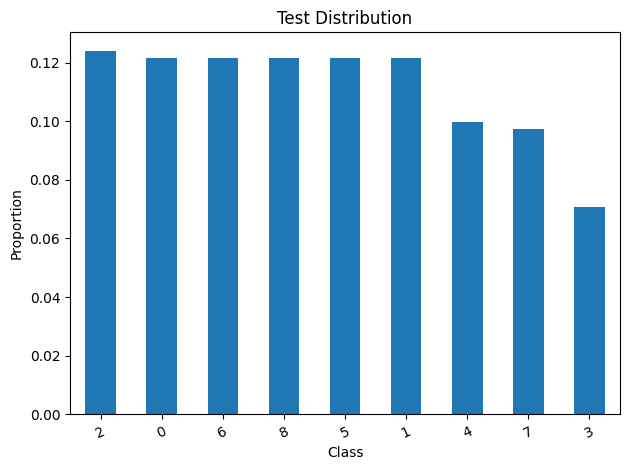

In [64]:
def plot_dist(df, title):
    df['label_id'].value_counts(normalize=True).plot(
        kind='bar'
    )
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Proportion")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

plot_dist(train_df, "Train Distribution")
plot_dist(val_df, "Validation Distribution")
plot_dist(test_df, "Test Distribution")

In [65]:
#Transforms
#train: Augmentation for overfit low
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

#test:Resize & Normalize
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])

])

In [66]:
from genericpath import isfile

class MyCustomeData(Dataset):
    def __init__(self, dataframe, transform=None):
        self.paths = dataframe['image'].values
        self.labels = dataframe['label_id'].values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img_path = self.paths[idx]
        img = Image.open(img_path).convert("RGB")

        label = int(self.labels[idx])

        if self.transform:
            img = self.transform(img)

        return img, label

In [67]:
df['label_id'], uniques = pd.factorize(df['label'])

# Prepare dataframes with 'image' column for MyCustomeData
train_df_for_dataset = train_df.rename(columns={'image_path': 'image'})
test_df_for_dataset = test_df.rename(columns={'image_path': 'image'})
val_df_for_dataset = val_df.rename(columns={'image_path': 'image'})

# Create datasets

train_dataset_full = MyCustomeData(train_df_for_dataset, train_transform)
test_dataset_full = MyCustomeData(test_df_for_dataset, test_transform)
valid_dataset_full = MyCustomeData(val_df_for_dataset, valid_transform)
num_classes = len(uniques)

print("Number of classes:", num_classes)
print("Full train size:", len(train_dataset_full))
print("Full test size:", len(test_dataset_full))
print("Full val size:", len(valid_dataset_full))

Number of classes: 9
Full train size: 3287
Full test size: 411
Full val size: 411


In [68]:
train_dataset = Subset(train_dataset_full, list(range (0, len(train_dataset_full))))
test_dataset = Subset(test_dataset_full, list(range(0, len(test_dataset_full))))
valid_dataset = Subset(valid_dataset_full, list(range(0, len(valid_dataset_full))))

In [69]:
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Val size:", len(valid_dataset))

Train size: 3287
Test size: 411
Val size: 411


In [70]:
#DataLoaders
pin = device.type == 'cuda'
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          pin_memory=pin, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          pin_memory=pin, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False,
                          pin_memory=pin, num_workers=2)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')
print(f'Val batches:   {len(valid_loader)}')

Train batches: 103
Test batches:  13
Val batches:   13


In [71]:
from collections import Counter
import torch

# y_train theke shorashori label gulo nao
train_labels = y_train.tolist()   # ba list(y_train)

counts = Counter(train_labels)
total  = sum(counts.values())

# Small sample er class beshi weight pabe
class_weights = torch.tensor(
    [total / counts[i] for i in range(num_classes)],
    dtype=torch.float
).to(device)

print('Class Weights:', class_weights)

Class Weights: tensor([ 8.2175,  8.2175,  8.1361, 14.1681,  9.9305,  8.2175,  8.2175, 10.2719,
         8.2175])


In [72]:
class MyCNNs(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: Edge & basic feature
            nn.Conv2d(3, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding='same'),  # double convo
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 128to64
            nn.Dropout2d(0.1),

            # Block 2: Mid-level feature
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 64to32
            nn.Dropout2d(0.15),

            # Block 3: High-level feature
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 32to16
            nn.Dropout2d(0.2),

            # Block 4 — Abstract feature
            nn.Conv2d(128, 256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 16to8
            nn.Dropout2d(0.2),

            # Block 5 — Deep abstract
            nn.Conv2d(256, 512, kernel_size=3, padding='same'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),   # size->independent
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [73]:
model = MyCNNs(num_classes=num_classes).to(device)

In [74]:
import torchsummary

torchsummary.summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         MaxPool2d-7           [-1, 32, 64, 64]               0
         Dropout2d-8           [-1, 32, 64, 64]               0
            Conv2d-9           [-1, 64, 64, 64]          18,496
      BatchNorm2d-10           [-1, 64, 64, 64]             128
             ReLU-11           [-1, 64, 64, 64]               0
           Conv2d-12           [-1, 64, 64, 64]          36,928
      BatchNorm2d-13           [-1, 64, 64, 64]             128
             ReLU-14           [-1, 64,

In [75]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=2e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print('Criterion, Optimizer, Scheduler ready ')

Criterion, Optimizer, Scheduler ready 


In [ ]:
import os # Needed for os.path.isfile

# Helper function to check if a file is an image
def is_image_file(filepath):
    # List of common image extensions
    IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff')
    return os.path.isfile(filepath) and filepath.lower().endswith(IMG_EXTENSIONS)

# Filter the dataframes to ensure only image files are included
# These dataframes (train_df, val_df, test_df) are already defined globally
train_df_filtered = train_df[train_df['image_path'].apply(is_image_file)].reset_index(drop=True)
val_df_filtered = val_df[val_df['image_path'].apply(is_image_file)].reset_index(drop=True)
test_df_filtered = test_df[test_df['image_path'].apply(is_image_file)].reset_index(drop=True)

# Prepare dataframes with 'image' column for MyCustomeData (renaming 'image_path' to 'image')
train_df_for_dataset = train_df_filtered.rename(columns={'image_path': 'image'})
test_df_for_dataset = test_df_filtered.rename(columns={'image_path': 'image'})
val_df_for_dataset = val_df_filtered.rename(columns={'image_path': 'image'})

# Re-create datasets (MyCustomeData and transforms are expected to be defined in previous cells)
train_dataset_full = MyCustomeData(train_df_for_dataset, train_transform)
test_dataset_full = MyCustomeData(test_df_for_dataset, test_transform)
valid_dataset_full = MyCustomeData(val_df_for_dataset, valid_transform)

# Re-create Subset datasets (Subset is expected to be imported in previous cells)
train_dataset = Subset(train_dataset_full, list(range (0, len(train_dataset_full))))
test_dataset = Subset(test_dataset_full, list(range(0, len(test_dataset_full))))
valid_dataset = Subset(valid_dataset_full, list(range(0, len(valid_dataset_full))))

# Re-create DataLoaders (DataLoader and device are expected to be defined in previous cells)
pin = device.type == 'cuda'
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          pin_memory=pin, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          pin_memory=pin, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False,
                          pin_memory=pin, num_workers=2)

# Continue with the original training loop code
epochs        = 10
patience      = 3
counter       = 0
best_val_loss = float('inf')

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []


def epoch_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            _, pred = torch.max(out, 1)
            correct += (pred == lbls).sum().item()
            total   += lbls.size(0)
    return correct / total


for epoch in range(epochs):

    # Train
    model.train()
    total_loss = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # Validation (fixed: valid_loader use kora hocche, test_loader na)
    model.eval()
    v_loss = 0
    with torch.no_grad():
        for imgs, lbls in valid_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            v_loss += criterion(out, lbls).item()
    val_loss = v_loss / len(valid_loader)

    t_acc = epoch_accuracy(train_loader)
    v_acc = epoch_accuracy(valid_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)

    scheduler.step(val_loss)

    print(f'Epoch {epoch+1:3d} | '
          f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
          f'Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f}')

    # Best model save
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'Best model saved! Val Loss: {val_loss:.4f} | Val Acc: {v_acc:.4f}')
    else:
        counter += 1

    if counter >= patience:
        print('\n Early stopping triggered!')
        break

print('\nTraining complete!')

Epoch   1 | Train Loss: 2.1381 | Val Loss: 1.9998 | Train Acc: 0.2603 | Val Acc: 0.2871
Best model saved! Val Loss: 1.9998 | Val Acc: 0.2871
Epoch   2 | Train Loss: 2.0798 | Val Loss: 2.0059 | Train Acc: 0.2819 | Val Acc: 0.2774


In [ ]:
def evaluate(loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
    return correct / total